# Project AI

## Greedy Algo

In [45]:
import pandas as pd
import numpy as np
import random
from functools import lru_cache
import matplotlib.pyplot as plt

Step 1: Problem Representation

1.1 Defining the Dough Roll
The roll of dough has a length of 500 units, which represents a one-dimensional space. We need to represent this space in Python to facilitate the placement of biscuits and track defects.

Implementation: Use a Python list of size 500, initialized to track each unit's availability and defect information.

Motivation: A list is ideal for representing sequential positions, enabling efficient indexing to check biscuit placement and defect status.

In [41]:
roll_length = 500
dough = [None] * roll_length

Step 2: Representing Defects

2.1 Defects Information
Defects have a class (e.g., 'a', 'b', 'c') and a position on the dough. We need to track the number of defects at each position.

Implementation: Use a dictionary where keys are positions on the dough roll, and values are dictionaries of defect classes.

Motivation: A dictionary allows us to efficiently store and retrieve defect information at specific positions without scanning the entire roll.

In [33]:
defects_df = pd.read_csv('defects.csv', sep=',')
print("Available columns:", defects_df.columns)
defects_df.columns = defects_df.columns.str.strip().str.lower()
if 'x' in defects_df.columns and 'class' in defects_df.columns:
    defects = {}
    for _, row in defects_df.iterrows():
        position = int(row['x'])
        defect_class = row['class']
        if position not in defects:
            defects[position] = {'a': 0, 'b': 0, 'c': 0}
        defects[position][defect_class] += 1
else:
    raise KeyError("Columns 'x' and 'class' are not found in the CSV file.")

Available columns: Index(['x', 'class'], dtype='object')


Step 3: Representing Biscuits

3.1 Biscuit Types
We need to represent four types of biscuits, each with a specific size, value, and defect tolerance. This can be represented using a class or a namedtuple.

Implementation: Use a list of dictionaries to represent biscuit types, including size, value, and tolerance levels for each defect type.

Motivation: A list of dictionaries provides an easy way to iterate through all biscuit types, and each biscuit's attributes can be accessed with meaningful keys.

In [34]:
biscuits = [
    {"id": 0, "length": 4, "value": 3, "thresholds": {'a': 4, 'b': 2, 'c': 3}},
    {"id": 1, "length": 8, "value": 12, "thresholds": {'a': 5, 'b': 4, 'c': 4}},
    {"id": 2, "length": 2, "value": 1, "thresholds": {'a': 1, 'b': 2, 'c': 1}},
    {"id": 3, "length": 5, "value": 8, "thresholds": {'a': 2, 'b': 3, 'c': 2}}
]

Step 4: Placing Biscuits on the Dough

4.1 Valid Placement Function
We need to determine if a given biscuit can be placed at a specific position.

Implementation: Define a function is_valid_placement(biscuit, position, occupied_positions) that checks if placing the biscuit at the specified position would respect size constraints and defect thresholds.

Motivation: Encapsulating this logic in a function allows for easy reuse, especially during optimization.

In [35]:
def is_valid_placement(biscuit, position, occupied_positions):
    biscuit_length = biscuit['length']
    thresholds = biscuit['thresholds']

    # Check if the biscuit exceeds roll length
    if position + biscuit_length > roll_length:
        return False

    # Check if positions are already occupied
    if any(occupied_positions[position:position + biscuit_length]):
        return False

    # Check the defect thresholds
    defect_counts = {'a': 0, 'b': 0, 'c': 0}
    for i in range(position, position + biscuit_length):
        if i in defects:
            for defect_class, count in defects[i].items():
                defect_counts[defect_class] += count
                if defect_counts[defect_class] > thresholds.get(defect_class, 0):
                    return False

    return True

4.2 Placing the Biscuit If a placement is valid, we can proceed to assign that biscuit to the roll.

  Implementation: Define a function place_biscuits(biscuits, roll_length) that marks the occupied positions and calculates the total value.

  Motivation: This helps in tracking the occupied parts of the dough to ensure no overlapping.

In [36]:
def place_biscuits_by_size(biscuits, roll_length):
    occupied_positions = np.zeros(roll_length, dtype=bool)
    placements = []
    total_value = 0

    # Sort biscuits by length in descending order to prioritize larger biscuits
    biscuits = sorted(biscuits, key=lambda x: x['length'], reverse=True)

    # Place each type of biscuit fully before moving to the next smaller size
    for biscuit in biscuits:
        while True:
            placed = False
            for position in range(roll_length - biscuit['length'] + 1):
                if is_valid_placement(biscuit, position, occupied_positions):
                    placements.append((biscuit['id'], position))
                    total_value += biscuit['value']
                    occupied_positions[position:position + biscuit['length']] = True
                    placed = True
                    break

            if not placed:
                break

    # Calculate the penalties for empty spaces
    unused_positions = np.sum(~occupied_positions)
    total_value -= unused_positions

    return placements, total_value

placements, total_value = place_biscuits_by_size(biscuits, roll_length)

print("Biscuit placements:", placements)
print("Total value (including penalties):", total_value)

Biscuit placements: [(1, 0), (1, 8), (1, 16), (1, 24), (1, 40), (1, 51), (1, 59), (1, 67), (1, 75), (1, 83), (1, 98), (1, 119), (1, 127), (1, 144), (1, 158), (1, 167), (1, 175), (1, 187), (1, 195), (1, 203), (1, 211), (1, 219), (1, 227), (1, 236), (1, 244), (1, 252), (1, 260), (1, 270), (1, 278), (1, 286), (1, 294), (1, 302), (1, 310), (1, 318), (1, 326), (1, 334), (1, 342), (1, 354), (1, 373), (1, 382), (1, 390), (1, 398), (1, 406), (1, 414), (1, 422), (1, 432), (1, 440), (1, 448), (1, 456), (1, 464), (1, 472), (1, 480), (1, 488), (3, 108), (3, 152), (0, 36), (0, 91), (0, 114), (0, 135), (0, 139), (0, 362), (0, 366), (0, 496), (2, 32), (2, 34), (2, 48), (2, 95), (2, 106), (2, 185), (2, 268), (2, 351), (2, 370)]
Total value (including penalties): 669


Step 6: Outputting Results

6.1 Evaluating the Solution
Calculate the total value of the solution, considering both the value of the biscuits and the penalties for empty positions.

Implementation: Print or log the total value and arrangement of biscuits.

Motivation: Evaluating the solution helps verify the implementation and informs further optimization.

In [37]:
print(f'Total value of the solution: {total_value}')

Total value of the solution: 669


## Genetic Algorithm with Optimized Random Initialization

In [29]:
biscuits = [
    {"id": 0, "length": 4, "value": 3, "thresholds": {'a': 4, 'b': 2, 'c': 3}},
    {"id": 1, "length": 8, "value": 12, "thresholds": {'a': 5, 'b': 4, 'c': 4}},
    {"id": 2, "length": 2, "value": 1, "thresholds": {'a': 1, 'b': 2, 'c': 1}},
    {"id": 3, "length": 5, "value": 8, "thresholds": {'a': 2, 'b': 3, 'c': 2}}
]

roll_length = 500
population_size = 500
generations = 100
max_attempts = 5000

# Function to check if placement is valid
def is_valid_placement(biscuit, position, occupied_positions):
    biscuit_length = biscuit['length']
    thresholds = biscuit['thresholds']

    if position + biscuit_length > roll_length:
        return False

    if any(occupied_positions[position:position + biscuit_length]):
        return False

    defect_counts = {'a': 0, 'b': 0, 'c': 0}
    for i in range(position, position + biscuit_length):
        if i in defects:
            for defect_class in defects[i]:
                defect_counts[defect_class] += 1
                if defect_counts[defect_class] > thresholds.get(defect_class, 0):
                    return False

    return True

# Function to evaluate fitness of a solution
def evaluate_fitness(placements, roll_length):
    total_value = sum(biscuit['value'] for biscuit, position in placements)
    occupied_positions = np.zeros(roll_length, dtype=bool)
    for biscuit, position in placements:
        occupied_positions[position:position + biscuit['length']] = True
    unused_positions = np.sum(~occupied_positions)
    total_value -= unused_positions
    return total_value

# Function to create an individual by placing biscuits to achieve fewer than 30 empty spaces
def create_individual():
    best_individual = None
    min_unused_positions = roll_length

    for _ in range(max_attempts):
        occupied_positions = np.zeros(roll_length, dtype=bool)
        individual = []

        # Sort biscuits by length in descending order to prioritize larger biscuits
        sorted_biscuits = sorted(biscuits, key=lambda x: x['length'], reverse=True)

        # Attempt to place each biscuit as many times as possible
        for biscuit in sorted_biscuits:
            for _ in range(random.randint(2, 500)):
                position = random.randint(0, roll_length - biscuit['length'])
                if is_valid_placement(biscuit, position, occupied_positions):
                    individual.append((biscuit, position))
                    occupied_positions[position:position + biscuit['length']] = True

        unused_positions = np.sum(~occupied_positions)

        if unused_positions < 30:
            return individual
        elif unused_positions < min_unused_positions:
            min_unused_positions = unused_positions
            best_individual = individual

    return best_individual

# Function to mutate an individual
def mutate(individual):
    if len(individual) > 0:
        index = random.randint(0, len(individual) - 1)
        biscuit, _ = individual[index]
        new_position = random.randint(0, roll_length - biscuit['length'])
        individual[index] = (biscuit, new_position)
    return individual

# Function to perform crossover between two parents
def crossover(parent1, parent2):
    child1 = []
    child2 = []

    # Use half elements from each parent
    for i in range(min(len(parent1), len(parent2))):
        if random.random() < 0.5:
            child1.append(parent1[i])
            child2.append(parent2[i])
        else:
            child1.append(parent2[i])
            child2.append(parent1[i])

    # Make sure to remove overlapping placements
    child1 = remove_overlaps(child1)
    child2 = remove_overlaps(child2)

    return child1, child2

# Function to remove overlapping placements in a child
def remove_overlaps(child):
    occupied_positions = np.zeros(roll_length, dtype=bool)
    valid_child = []
    for biscuit, position in child:
        if is_valid_placement(biscuit, position, occupied_positions):
            valid_child.append((biscuit, position))
            occupied_positions[position:position + biscuit['length']] = True
    return valid_child

# Function to run the genetic algorithm
def genetic_algorithm():
    population = [create_individual() for _ in range(population_size)]

    for generation in range(generations):
        fitness_values = []
        for individual in population:
            fitness = evaluate_fitness(individual, roll_length)
            fitness_values.append((fitness, individual))

        fitness_values.sort(reverse=True, key=lambda x: x[0])

        # Select the best individuals for the next generation
        next_generation = [individual for _, individual in fitness_values[:population_size // 2]]

        # Perform crossover to create children
        children = []
        while len(children) < population_size // 2:
            parent1, parent2 = random.sample(next_generation, 2)
            child1, child2 = crossover(parent1, parent2)
            children.append(child1)
            children.append(child2)

        # Mutate children
        for i in range(len(children)):
            if random.random() < 0.3:
                children[i] = mutate(children[i])

        population = next_generation + children

        best_fitness = fitness_values[0][0]

    best_individual = max(population, key=lambda ind: evaluate_fitness(ind, roll_length))
    return best_individual

best_solution = genetic_algorithm()

final_value = evaluate_fitness(best_solution, roll_length)

final_placements = [(biscuit['id'], position) for biscuit, position in best_solution]
print("Biscuit placements (Genetic Algorithm with Optimized Random Initialization):", final_placements)
print("Total value (including penalties):", final_value)

Biscuit placements (Genetic Algorithm with Optimized Random Initialization): [(1, 127), (1, 251), (1, 302), (1, 313), (1, 341), (1, 71), (1, 391), (1, 465), (1, 374), (1, 266), (1, 409), (1, 197), (1, 229), (1, 492), (1, 18), (1, 444), (1, 105), (1, 354), (1, 294), (1, 436), (1, 280), (1, 7), (1, 420), (1, 40), (1, 210), (1, 168), (1, 158), (1, 187), (1, 28), (1, 219), (1, 329), (1, 80), (1, 176), (1, 51), (1, 484), (1, 242), (1, 119), (1, 399), (1, 474), (1, 383), (1, 148), (1, 88), (1, 452), (1, 60), (3, 288), (3, 237), (3, 349), (3, 322), (3, 260), (3, 99), (3, 460), (3, 2), (3, 205), (0, 135), (0, 429), (0, 366), (0, 144), (0, 370), (0, 275), (0, 139), (0, 337), (0, 114), (0, 36), (2, 69), (2, 327), (2, 185), (2, 434), (2, 310), (2, 16), (2, 26), (2, 417), (2, 363), (2, 407), (2, 227), (2, 48)]
Total value (including penalties): 603


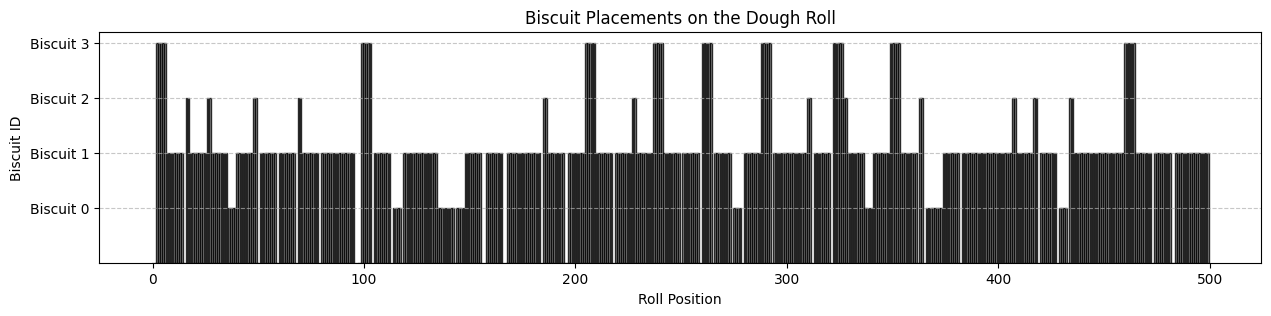

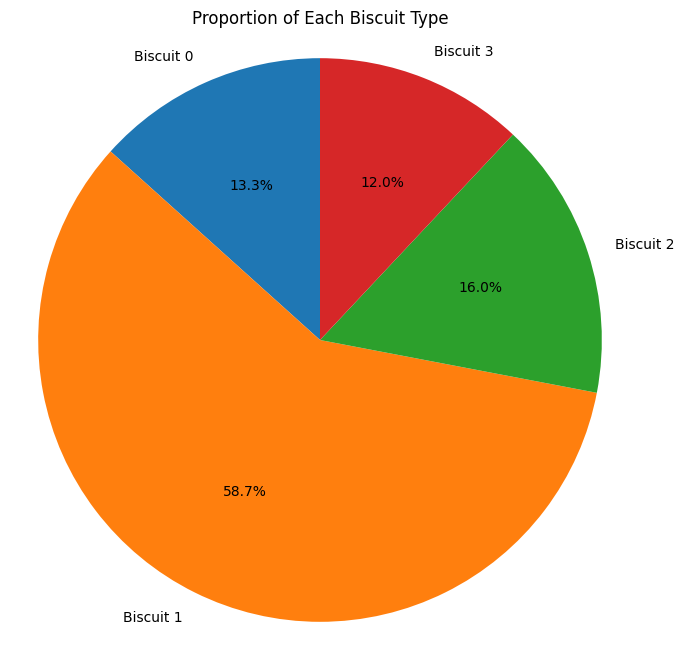

In [30]:
import matplotlib.pyplot as plt

# Function to visualize the distribution of biscuits on the roll
def visualize_distribution(best_solution, biscuits, roll_length):
    roll_visual = np.zeros(roll_length, dtype=int)
    for biscuit, position in best_solution:
        roll_visual[position:position + biscuit['length']] = biscuit['id'] + 1

    plt.figure(figsize=(15, 3))
    plt.bar(range(roll_length), roll_visual, color='gray', edgecolor='black', alpha=0.8)
    plt.xlabel('Roll Position')
    plt.ylabel('Biscuit ID')
    plt.title('Biscuit Placements on the Dough Roll')
    plt.yticks(range(1, len(biscuits) + 1), [f"Biscuit {b['id']}" for b in biscuits])
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

# Function to create a pie chart for the distribution of biscuits
def biscuit_pie_chart(best_solution, biscuits):
    biscuit_counts = {biscuit['id']: 0 for biscuit in biscuits}
    for biscuit, _ in best_solution:
        biscuit_counts[biscuit['id']] += 1

    labels = [f"Biscuit {b['id']}" for b in biscuits]
    sizes = [biscuit_counts[b['id']] for b in biscuits]

    plt.figure(figsize=(8, 8))
    plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90, colors=plt.cm.tab10.colors)
    plt.title("Proportion of Each Biscuit Type")
    plt.axis('equal')
    plt.show()

visualize_distribution(best_solution, biscuits, roll_length)
biscuit_pie_chart(best_solution, biscuits)


## Dynamic programming

In [43]:
ROLL_LENGTH = 500

biscuits = [
    {"length": 4, "value": 3, "defects": {"a": 4, "b": 2, "c": 3}},
    {"length": 8, "value": 12, "defects": {"a": 5, "b": 4, "c": 4}},
    {"length": 2, "value": 1, "defects": {"a": 1, "b": 2, "c": 1}},
    {"length": 5, "value": 8, "defects": {"a": 2, "b": 3, "c": 2}},
]

defect_map = {x: {"a": 0, "b": 0, "c": 0} for x in range(ROLL_LENGTH)}
for _, row in defects_df.iterrows():
    position = int(row["x"])
    defect_class = row["class"]
    if 0 <= position < ROLL_LENGTH:
        defect_map[position][defect_class] += 1

# Memoization for dynamic programming
@lru_cache(None)
def solve(position):
    if position >= ROLL_LENGTH:
        return 0, []

    max_value = -ROLL_LENGTH
    best_solution = []

    for idx, biscuit in enumerate(biscuits):
        b_len, b_val, b_def = biscuit["length"], biscuit["value"], biscuit["defects"]
        if position + b_len > ROLL_LENGTH:
            continue

        # Check if placing this biscuit is valid
        is_valid = True
        defect_count = {"a": 0, "b": 0, "c": 0}
        for i in range(position, position + b_len):
            for d_class in defect_count:
                defect_count[d_class] += defect_map[i][d_class]
            if any(defect_count[d] > b_def[d] for d in b_def):
                is_valid = False
                break

        if not is_valid:
            continue

        # Recursively solve for the next position
        next_value, next_solution = solve(position + b_len)
        total_value = b_val + next_value
        if total_value > max_value:
            max_value = total_value
            best_solution = [(position, idx)] + next_solution

    # Consider skipping the current position
    skip_value, skip_solution = solve(position + 1)
    skip_value -= 1
    if skip_value > max_value:
        max_value = skip_value
        best_solution = skip_solution

    return max_value, best_solution

max_value, solution = solve(0)

placed_biscuits = [
    {"start_position": pos, "biscuit_index": idx, **biscuits[idx]}
    for pos, idx in solution
]
unused_positions = set(range(ROLL_LENGTH)) - {
    pos for start, idx in solution for pos in range(start, start + biscuits[idx]["length"])
}
final_score = max_value - len(unused_positions)

print("Placed Biscuits:", placed_biscuits)
print("Final Score:", final_score)
print("Unused Positions Count:", len(unused_positions))


Placed Biscuits: [{'start_position': 0, 'biscuit_index': 1, 'length': 8, 'value': 12, 'defects': {'a': 5, 'b': 4, 'c': 4}}, {'start_position': 8, 'biscuit_index': 1, 'length': 8, 'value': 12, 'defects': {'a': 5, 'b': 4, 'c': 4}}, {'start_position': 16, 'biscuit_index': 1, 'length': 8, 'value': 12, 'defects': {'a': 5, 'b': 4, 'c': 4}}, {'start_position': 24, 'biscuit_index': 2, 'length': 2, 'value': 1, 'defects': {'a': 1, 'b': 2, 'c': 1}}, {'start_position': 26, 'biscuit_index': 3, 'length': 5, 'value': 8, 'defects': {'a': 2, 'b': 3, 'c': 2}}, {'start_position': 31, 'biscuit_index': 3, 'length': 5, 'value': 8, 'defects': {'a': 2, 'b': 3, 'c': 2}}, {'start_position': 36, 'biscuit_index': 0, 'length': 4, 'value': 3, 'defects': {'a': 4, 'b': 2, 'c': 3}}, {'start_position': 40, 'biscuit_index': 1, 'length': 8, 'value': 12, 'defects': {'a': 5, 'b': 4, 'c': 4}}, {'start_position': 48, 'biscuit_index': 2, 'length': 2, 'value': 1, 'defects': {'a': 1, 'b': 2, 'c': 1}}, {'start_position': 50, 'bi

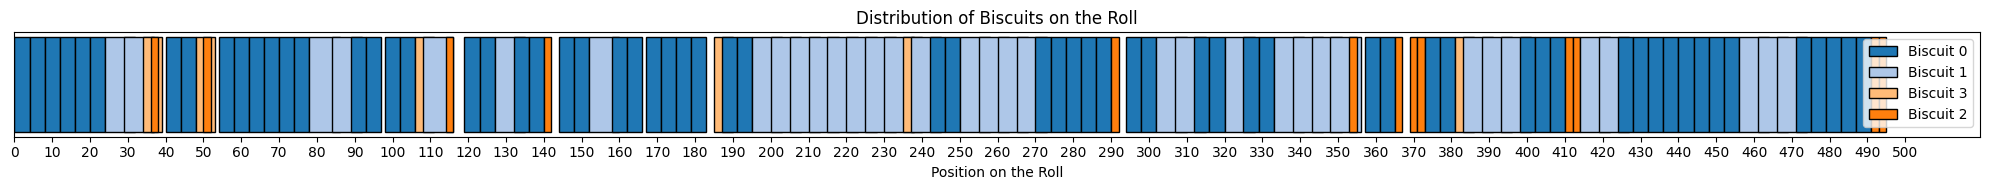

In [44]:
import matplotlib.pyplot as plt

def plot_roll_distribution(roll_length, final_solution, biscuits):
    roll = ["Empty"] * roll_length

    for start, idx in final_solution:
        biscuit_length = biscuits[idx]["length"]
        if start + biscuit_length > roll_length:
            print(f"Warning: Biscuit {idx} at position {start} exceeds roll length.")
            continue
        for pos in range(start, start + biscuit_length):
            roll[pos] = f"Biscuit {idx}"

    plt.figure(figsize=(20, 2))
    colors = plt.cm.tab20(range(len(biscuits)))

    for start, idx in final_solution:
        biscuit_length = biscuits[idx]["length"]
        if start + biscuit_length > roll_length:
            continue
        plt.barh(
            0,
            width=biscuit_length,
            left=start,
            color=colors[idx % len(colors)],
            edgecolor="black",
            label=f"Biscuit {idx}" if f"Biscuit {idx}" not in plt.gca().get_legend_handles_labels()[1] else None,
        )

    plt.yticks([])
    plt.xticks(range(0, roll_length + 1, 10))
    plt.title("Distribution of Biscuits on the Roll")
    plt.xlabel("Position on the Roll")
    plt.legend(loc="upper right")
    plt.tight_layout()
    plt.show()

plot_roll_distribution(ROLL_LENGTH, final_solution, biscuits)


## Simulated annealing with random optimized initialisation

In [15]:
positions = pd.DataFrame({'x': np.arange(500)})
defects_summary = pd.merge(
    positions,
    pd.crosstab(defects['x'], defects['class']),
    how='left',
    left_on='x',
    right_index=True
).fillna(0)

biscuits = [
    {"length": 4, "value": 3, "thresholds": {'a': 4, 'b': 2, 'c': 3}},
    {"length": 8, "value": 12, "thresholds": {'a': 5, 'b': 4, 'c': 4}},
    {"length": 2, "value": 1, "thresholds": {'a': 1, 'b': 2, 'c': 1}},
    {"length": 5, "value": 8, "thresholds": {'a': 2, 'b': 3, 'c': 2}},
]

ROLL_LENGTH = 500
PENALTY = -0.5
POPULATION_SIZE = 60
GENERATIONS = 75
MAX_ATTEMPTS = 200

def is_valid_placement(biscuit, position, occupied_positions):
    positions = range(position, position + biscuit['length'])

    if any(occupied_positions[pos] for pos in positions):
        return False

    for pos in positions:
        if pos in defects_summary['x'].values:
            for defect_class, threshold in biscuit['thresholds'].items():
                defect_count = defects_summary.loc[defects_summary['x'] == pos, defect_class].values[0]
                if defect_count > threshold:
                    return False

    return True

def create_individual():
    min_unused_positions = ROLL_LENGTH
    best_individual = []

    for _ in range(MAX_ATTEMPTS):
        occupied_positions = np.zeros(ROLL_LENGTH, dtype=bool)
        individual = []

        sorted_biscuits = sorted(
            enumerate(biscuits),
            key=lambda x: (x[1]['value'] / x[1]['length'], -x[1]['length']),
            reverse=True
        )

        for biscuit_index, biscuit in sorted_biscuits:
            for _ in range(random.randint(2, 500)):
                position = random.randint(0, ROLL_LENGTH - biscuit['length'])
                if is_valid_placement(biscuit, position, occupied_positions):
                    individual.append({"type": biscuit_index, "start": position})
                    occupied_positions[position:position + biscuit['length']] = True

        unused_positions = np.sum(~occupied_positions)

        if unused_positions < 30:
            return individual
        elif unused_positions < min_unused_positions:
            min_unused_positions = unused_positions
            best_individual = individual

    return best_individual


def generate_initial_population(pop_size):
    return [create_individual() for _ in range(pop_size)]

def calculate_value(arrangement):
    total_value = 0
    used_positions = set()

    for biscuit in arrangement:
        start = biscuit['start']
        biscuit_type = biscuit['type']
        biscuit_def = biscuits[biscuit_type]
        positions = range(start, start + biscuit_def['length'])

        if used_positions & set(positions):
            return float('-inf')

        for pos in positions:
            if pos in defects_summary['x'].values:
                for defect_class, threshold in biscuit_def['thresholds'].items():
                    defect_count = defects_summary.loc[defects_summary['x'] == pos, defect_class].values[0]
                    if defect_count > threshold:
                        return float('-inf')

        used_positions.update(positions)
        total_value += biscuit_def['value']

    unused_positions = ROLL_LENGTH - len(used_positions)
    return total_value + PENALTY * unused_positions

def generate_neighbor(arrangement):
    neighbor = arrangement.copy()
    if neighbor and random.random() < 0.5:
        neighbor.pop(random.randint(0, len(neighbor) - 1))
    else:
        biscuit_type = random.randint(0, len(biscuits) - 1)
        start = random.randint(0, ROLL_LENGTH - biscuits[biscuit_type]['length'])
        positions = range(start, start + biscuits[biscuit_type]['length'])


        valid = True
        for pos in positions:
            if pos in defects_summary['x'].values:
                for defect_class, threshold in biscuits[biscuit_type]['thresholds'].items():
                    defect_count = defects_summary.loc[defects_summary['x'] == pos, defect_class].values[0]
                    if defect_count > threshold:
                        valid = False
                        break
            if not valid:
                break

        if valid and not (set(positions) & set(pos for b in neighbor for pos in range(b['start'], b['start'] + biscuits[b['type']]['length']))):
            neighbor.append({"type": biscuit_type, "start": start})
    return neighbor


def simulated_annealing():
    temperature = 1000.0
    cooling_rate = 0.995
    current_solution = create_individual()
    best_solution = current_solution
    best_value = calculate_value(best_solution)

    while temperature > 1e-3:
        neighbor = generate_neighbor(current_solution)
        current_value = calculate_value(current_solution)
        neighbor_value = calculate_value(neighbor)

        if neighbor_value > current_value or random.random() < np.exp((neighbor_value - current_value) / temperature):
            current_solution = neighbor

        if calculate_value(current_solution) > best_value:
            best_solution = current_solution
            best_value = calculate_value(best_solution)

        temperature *= cooling_rate

    return best_solution, best_value

def fill_gaps(solution):
    used_positions = set()
    for biscuit in solution:
        used_positions.update(range(biscuit['start'], biscuit['start'] + biscuits[biscuit['type']]['length']))

    for gap_start in range(ROLL_LENGTH):
        if gap_start not in used_positions:
            for biscuit_type, biscuit_def in enumerate(biscuits):
                gap_positions = range(gap_start, gap_start + biscuit_def['length'])
                if all(pos not in used_positions for pos in gap_positions) and all(
                    defects_summary.loc[defects_summary['x'] == pos, defect_class].values[0] <= biscuit_def['thresholds'][defect_class]
                    for pos in gap_positions
                    for defect_class in biscuit_def['thresholds']
                    if pos in defects_summary['x'].values
                ):
                    solution.append({"type": biscuit_type, "start": gap_start})
                    used_positions.update(gap_positions)
                    break
    return solution

best_solution, best_value = simulated_annealing()
print("Best Solution:", best_solution)
print("Best Value:", best_value)

final_solution = fill_gaps(best_solution)
print("Final Solution:", final_solution)
print("Final Value:", calculate_value(final_solution))


Best Solution: [{'type': 3, 'start': 482}, {'type': 3, 'start': 201}, {'type': 3, 'start': 398}, {'type': 3, 'start': 430}, {'type': 3, 'start': 278}, {'type': 3, 'start': 59}, {'type': 3, 'start': 79}, {'type': 3, 'start': 117}, {'type': 3, 'start': 130}, {'type': 3, 'start': 22}, {'type': 1, 'start': 232}, {'type': 1, 'start': 243}, {'type': 1, 'start': 43}, {'type': 1, 'start': 472}, {'type': 1, 'start': 442}, {'type': 1, 'start': 337}, {'type': 1, 'start': 450}, {'type': 1, 'start': 409}, {'type': 1, 'start': 383}, {'type': 1, 'start': 193}, {'type': 1, 'start': 462}, {'type': 1, 'start': 100}, {'type': 1, 'start': 173}, {'type': 1, 'start': 151}, {'type': 1, 'start': 350}, {'type': 1, 'start': 27}, {'type': 1, 'start': 183}, {'type': 1, 'start': 161}, {'type': 1, 'start': 489}, {'type': 1, 'start': 212}, {'type': 1, 'start': 302}, {'type': 1, 'start': 316}, {'type': 1, 'start': 109}, {'type': 1, 'start': 291}, {'type': 1, 'start': 143}, {'type': 1, 'start': 418}, {'type': 1, 'star

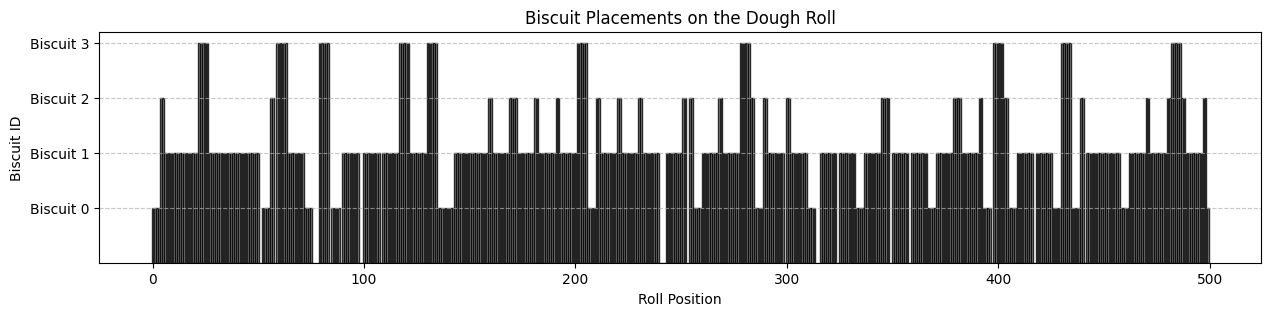

In [21]:
def visualize_distribution(solution, biscuits, roll_length):
    roll_visual = np.zeros(roll_length, dtype=int)
    for biscuit in solution:
        biscuit_type = biscuit['type']
        start = biscuit['start']
        roll_visual[start:start + biscuits[biscuit_type]['length']] = biscuit_type + 1

    plt.figure(figsize=(15, 3))
    plt.bar(range(roll_length), roll_visual, color='gray', edgecolor='black', alpha=0.8)
    plt.xlabel('Roll Position')
    plt.ylabel('Biscuit ID')
    plt.title('Biscuit Placements on the Dough Roll')
    plt.yticks(range(1, len(biscuits) + 1), [f"Biscuit {i}" for i in range(len(biscuits))])
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()


visualize_distribution(final_solution, biscuits, ROLL_LENGTH)